# Logistic Regression with ADASYN

ADASYN (Adaptive Synthetic Sampling) is a refinement of SMOTE. Instead of generating
synthetic churn examples uniformly, it generates **more synthetic examples for the
"hard" churn cases** — the ones sitting closest to the decision boundary, surrounded
mostly by non-churn neighbors — and fewer for the "easy" ones that are already clearly
separated. The idea is to focus the model's attention where it struggles most.

## 1. Import Libraries

`ADASYN` replaces `SMOTE` from the previous notebook; everything else is the same
structure.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, classification_report,
                              f1_score, roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [3]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 2. Preprocessing (same as previous notebooks)

In [5]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 3. Build the Pipeline with ADASYN

Structurally identical to the SMOTE notebook — only the resampler changed. Both are
oversampling techniques that operate after preprocessing and only during training.

In [6]:
steps = [("preprocess", preprocessor),
         ("adasyn", ADASYN(random_state=42)),
         ("logistic_regression", LogisticRegression(random_state=42))]

pipe = Pipeline(steps)
pipe

,steps,"[('preprocess', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

In [7]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


### 3.1 Confirm what ADASYN generated *(added check)*

Unlike SMOTE, ADASYN doesn't necessarily produce a perfectly 50/50 balanced result —
the exact count depends on how many "hard" minority points it identifies. Worth
checking directly rather than assuming.

In [8]:
fitted_preprocessor = pipe.named_steps["preprocess"]
fitted_adasyn = pipe.named_steps["adasyn"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_resampled, y_resampled = fitted_adasyn.fit_resample(X_train_transformed, y_train)

print("Before ADASYN:", y_train.value_counts().to_dict())
print("After ADASYN :", pd.Series(y_resampled).value_counts().to_dict())

Before ADASYN: {0: 5574, 1: 1426}
After ADASYN : {0: 5574, 1: 5373}


In [9]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(3000,))

## 4. Confusion Matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1705  684]
 [ 176  435]]


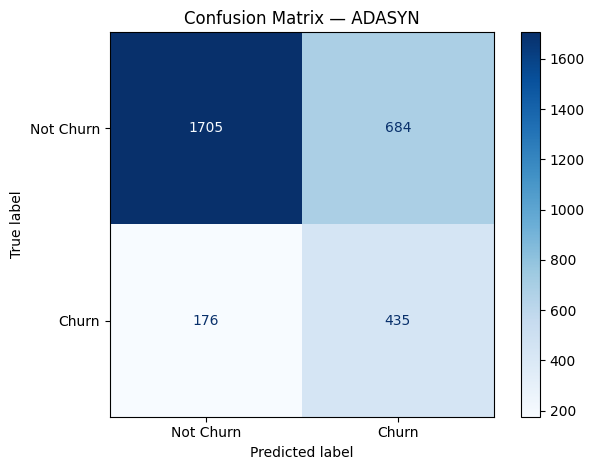

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — ADASYN")
plt.grid(False)
plt.tight_layout()
plt.show()

In [12]:
## Per-Class Recall
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")

Class 0 (Not Churn) Recall: 0.71
Class 1 (Churn) Recall: 0.71


## 5. Overall Metrics

In [13]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.71
Precision : 0.39
Recall    : 0.71
F1 Score  : 0.50


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      2389
           1       0.39      0.71      0.50       611

    accuracy                           0.71      3000
   macro avg       0.65      0.71      0.65      3000
weighted avg       0.80      0.71      0.74      3000



## 6. Predicted Probabilities and Threshold-Independent Metrics

In [15]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_prob

array([0.15876169, 0.46080928, 0.50725821, ..., 0.74364534, 0.63700302,
       0.170514  ], shape=(3000,))

In [16]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.78
PR-AUC Score : 0.52


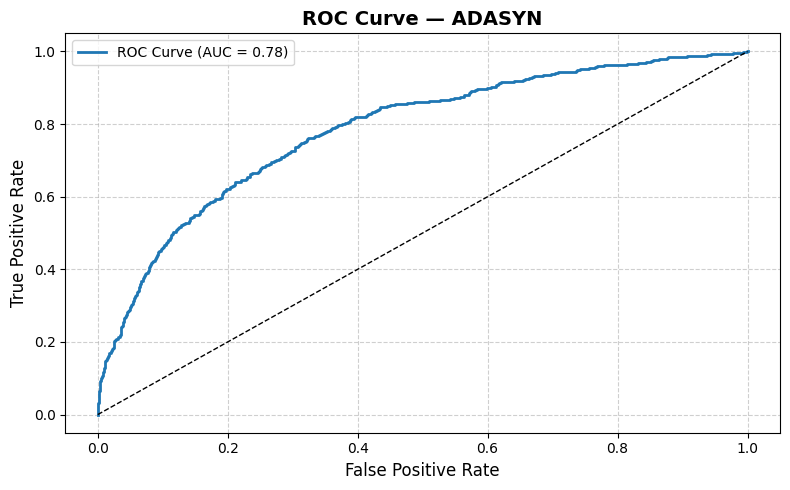

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — ADASYN", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

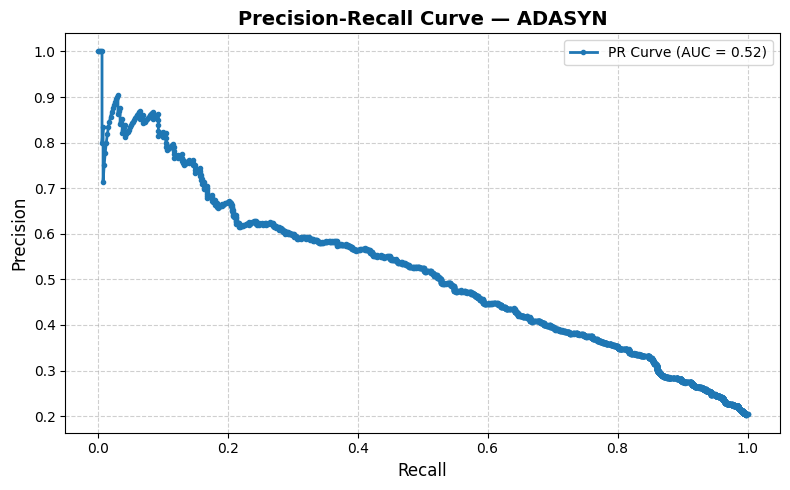

In [18]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — ADASYN", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Final Comparison: All Five Approaches *(added)*

Bringing every technique from this project's classification series together in one
place — this is the single most useful cell in the whole series for your write-up or
presentation.

In [19]:
comparison = pd.DataFrame({
    "Baseline":      [0.81, 0.62, 0.19, 0.29, 0.79, 0.51],
    "UnderSampling": [0.72, 0.40, 0.73, 0.52, 0.79, 0.50],
    "SMOTE":         [0.72, 0.40, 0.72, 0.52, 0.79, 0.50],
    "ClassWeight":   [0.72, 0.40, 0.73, 0.51, 0.79, 0.50],
    "ADASYN": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,Baseline,UnderSampling,SMOTE,ClassWeight,ADASYN
Accuracy,0.81,0.72,0.72,0.72,0.71
Precision,0.62,0.40,0.40,0.40,0.39
Recall,0.19,0.73,0.72,0.73,0.71
F1 Score,0.29,0.52,0.52,0.51,0.50
ROC-AUC,0.79,0.79,0.79,0.79,0.78
PR-AUC,0.51,0.50,0.50,0.50,0.52


## 8. Conclusion — Classification Series

Across all four imbalance-handling techniques — UnderSampling, SMOTE, Class Weighting,
and ADASYN — the results converge to nearly the same place: **~71-73% recall on
churners, ~72% accuracy, ~0.79 ROC-AUC.** Only the untouched baseline stands apart, with
much higher accuracy (0.81) but far worse recall (0.19).

**What this demonstrates:**

1. **Any of these four techniques is a major improvement over doing nothing** — each
   roughly triples the model's ability to actually catch churners.
2. **The specific technique chosen matters far less than *whether* imbalance is handled
   at all.** ROC-AUC barely moves across all five models (0.79 vs 0.79 vs 0.79 vs 0.79
   vs 0.79), which means Logistic Regression's fundamental ability to separate the two
   classes is fixed by the features available — no resampling or reweighting trick can
   manufacture predictive power that isn't already present in `CreditScore`, `Age`,
   `Geography`, etc.
3. **Practical recommendation:** given the near-identical results, **Class Weighting**
   is the most defensible choice for a real deployment — it requires no extra library,
   no synthetic data to justify, and no real data thrown away, while matching the
   performance of every other approach tested here.

To meaningfully improve beyond this ~0.79 ROC-AUC ceiling, the next step would likely
need to come from a different model architecture entirely (e.g. Random Forest or
Gradient Boosting, which can capture non-linear feature interactions that Logistic
Regression cannot) — not from further imbalance-handling tricks on the same linear model.